# Interpreting London Burglary: A Machine Learning Analysis of Deprivation

## Preparation

- [Github link](google.com) https://github.com/Louise0311/CASA0006_Assignment.git

- Number of words: 1494

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: Local installation (VS Code + Python 3.12.10)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **shap**: An Explainable AI (XAI) framework used for calculating and visualizing Shapley values to interpret model predictions.
    - **xgboost**: An optimized distributed gradient boosting library used for the implementation of the XGBRegressor model.
    - **statsmodels**: A Python module used specifically in this project for calculating the Variance Inflation Factor (VIF) to detect multicollinearity.
    - **scikit-learn**: Used for machine learning tasks including model training (Random Forest, Decision Tree), cross-validation, and performance metrics.

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Urban crime is not a random occurrence but a spatially concentrated phenomenon shaped by complex socio-economic landscapes (Tao, C. and Chen, T., 2021). In London, the distribution of burglary rates exhibits significant heterogeneity across Lower Layer Super Output Areas (LSOAs). Studying and predicting the patterns of theft cases is of positive significance for social governance and optimizing urban management policies (Yan, Z. et al., 2022; Chamberlain, A. W. and Boggess, L. N., 2016).  This study uses London crime data, census data, and social deprivation index data to filter and integrate the data, and processes the large dataset through machine learning, using algorithms to learn the patterns in the data and make predictions (Jose Triny et al., 2023). This report combines rigorous machine learning with visual diagnostics to provide an insightful framework for evidence-based urban safety interventions, and elaborates on the principles behind each analytical component in detail, from the overall to the specifics.

## Research questions

[[ go back to the top ]](#Table-of-contents)

What is the relationship between residential burglary rates and multiple dimensions of local deprivation in London at the LSOA level in 2025?

## Data

[[ go back to the top ]](#Table-of-contents)

### Data Sources
This research integrates three primary datasets to investigate the spatial relationship between deprivation and burglary rates in London:

[Crime Data](https://data.london.gov.uk/download/exy3m/nmy/MPS%20LSOA%20Level%20Crime%20(most%20recent%2024%20months).csv): Sourced from the [Metropolitan Police Service (MPS)](https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m/), providing LSOA-level crime counts. For this study, I specifically extracted records for "Burglary" from January to December 2025 to align with the latest deprivation indices.

[Deprivation Indices](https://assets.publishing.service.gov.uk/media/691decfae39a085bda43efcd/File_2_IoD2025_Domains_of_Deprivation.xlsx): Sourced from the [GOV.UK](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025). The Index of Multiple Deprivation (IoD) 2025 (File 2: Domains of Deprivation) provides multidimensional scores for 32,844 LSOAs in England, covering domains such as Income, Employment, and Living Environment.

[Population Estimates](https://www.ons.gov.uk/file?uri=/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/lowersuperoutputareamidyearpopulationestimates/mid2022revisednov2025tomid2024/sapelsoasyoa20222024.xlsx): Sourced from the [Office for National Statistics (ONS)](https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/lowersuperoutputareamidyearpopulationestimates). Mid-2024 population estimates for LSOAs in England and Wales were used as the denominator for calculating crime rates.

### Preprocessing and Cleaning

1. Filtering and Aggregation: Extract burglary data for 2025 from the original 24 months of data. Monthly counts were summed to generate an annual total per LSOA.
2. Data Type Conversion: Clean the population dataset by removing commas from data containing them (e.g., "1,200") and converting the strings to floating-point numbers for mathematical operations.
3. Spatial Scoping: Using an Inner Join between the England-wide Deprivation dataset and the London-specific crime data, the study area was precisely limited to the London area.
4. Normalization: To account for varying population densities across LSOAs, a Burglary Rate per 1,000 residents was calculated:$$Burglary\ Rate = \left( \frac{Total\ Burglary\ 2025}{Total\ Population} \right) \times 1000$$
5. Handling Missing Values: LSOAs present in the IMD data but missing from the crime records were assigned a value of 0, representing no recorded burglaries in 2025.

In [1]:
import pandas as pd
import numpy as np
import os

# 1. Define the data folder path
data_dir = 'data'

# 2. Build relative paths for local files
crime_path = os.path.join(data_dir, 'MPS LSOA Level Crime (most recent 24 months).csv')
pop_path = os.path.join(data_dir, 'population estimates2024.csv')
domains_path = os.path.join(data_dir, 'Domains for Deprivation.csv')

# 3. Read local data
# Reading crime data
df_crime = pd.read_csv(crime_path)

# Reading deprivation index data
df_domains = pd.read_csv(domains_path)

# Reading population data (keeping your previous skiprows=3 logic)
df_pop = pd.read_csv(pop_path, skiprows=3, low_memory=False)


In [2]:
# 4. Filter burglary data from 2025
# Define cols_2025: identify all columns starting with '2025'
cols_2025 = [c for c in df_crime.columns if c.startswith('2025')]

# 5. Preprocess crime data: filter burglary (Burglary)
# According to your suggestion, we focus on Residential Burglary
df_burglary_2025 = df_crime[df_crime['Major Category'] == 'BURGLARY'][['LSOA Code'] + cols_2025].copy()

# Calculate the total crime count for each LSOA in 2025
df_burglary_2025['Total_2025_Count'] = df_burglary_2025[cols_2025].sum(axis=1)

# Aggregate by LSOA (sum), ensuring each LSOA has only one row
lsoa_crime_2025 = df_burglary_2025.groupby('LSOA Code')['Total_2025_Count'].sum().reset_index()

# 6. Prepare population data
# Extract LSOA codes and total population columns
df_pop['Total'] = df_pop['Total'].astype(str).str.replace(',', '').astype(float)
df_pop_clean = df_pop[['LSOA 2021 Code', 'Total']].copy()
df_pop_clean.rename(columns={'Total': 'Total_Population', 'LSOA 2021 Code': 'LSOA_Code_Pop'}, inplace=True)

In [3]:
# 7. merge all data together

# Use df_domains as the benchmark directly, because it includes all sub-dimensions and the overall ranking.
# Step 1: Merge crime data
merged_df = pd.merge(df_domains, lsoa_crime_2025, left_on='LSOA code (2021)', right_on='LSOA Code', how='inner')

# Step 2: Merge population data
merged_df = pd.merge(merged_df, df_pop_clean, left_on='LSOA code (2021)', right_on='LSOA_Code_Pop', how='inner')


In [4]:
# Remove the auxiliary ID column used for merging.
final_df = merged_df.drop(columns=['LSOA Code', 'LSOA_Code_Pop'])

# Fill in areas without crime records with 0 and calculate crime rate
final_df['Total_2025_Count'] = final_df['Total_2025_Count'].fillna(0)
final_df['Burglary_Rate_2025(per_1000)'] = (final_df['Total_2025_Count'] / final_df['Total_Population']) * 1000

In [5]:
# Define the column names of dependent and independent variables.
# 8. Modify feature column names 
cols_to_use = [
    'Income Rank (where 1 is most deprived)',
    'Employment Rank (where 1 is most deprived)',
    'Education, Skills and Training Rank (where 1 is most deprived)',
    'Health Deprivation and Disability Rank (where 1 is most deprived)',
    'Barriers to Housing and Services Rank (where 1 is most deprived)',
    'Living Environment Rank (where 1 is most deprived)'
]

target_col = 'Burglary_Rate_2025(per_1000)'

### Summary of Variables
The table below describes the variables selected for the analysis of residential burglary rates and socio-economic deprivation in London.

| Variable Category | Column Name | Data Type | Description | Source |
| :--- | :--- | :--- | :--- | :--- |
| **Dependent Variable (y)** | `Burglary_Rate_2025` | Numerical (Continuous) | Average annual residential burglary rate | MPS Crime & Population |
| **Independent Variable (X1)** | `Income Domain Score` | Numerical (Discrete/Rank) | population experiencing income deprivation | Domains for Deprivation |
| **Independent Variable (X2)** | `Employment Domain Score` | Numerical (Discrete/Rank) | working-age population excluded from the labour market | Domains for Deprivation |
| **Independent Variable (X3)** | `Education, Skills and Training Score` | Numerical (Discrete/Rank) | lack of attainment and skills in the local population | Domains for Deprivation |
| **Independent Variable (X4)** | `Health Deprivation and Disability Score` | Numerical (Discrete/Rank) | risk of premature death and the impairment of quality of life | Domains for Deprivation |
| **Independent Variable (X5)** | `Barriers to Housing and Services Score` | Numerical (Discrete/Rank) | physical and financial accessibility of housing and local services | Domains for Deprivation |
| **Independent Variable (X6)** | `Living Environment Domain Score` | Numerical (Discrete/Rank) | quality of the local environment (housing and outdoors) | Domains for Deprivation |

### Data Preview

In [6]:
# 9. Preview the first few rows of data
final_df.head()


,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),...,Health Deprivation and Disability Decile (where 1 is most deprived 10% of LSOAs),Crime Rank (where 1 is most deprived),Crime Decile (where 1 is most deprived 10% of LSOAs),Barriers to Housing and Services Rank (where 1 is most deprived),Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs),Living Environment Rank (where 1 is most deprived),Living Environment Decile (where 1 is most deprived 10% of LSOAs),Total_2025_Count,Total_Population,Burglary_Rate_2025(per_1000)
0,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,10917,4,7519,3,15286,5,...,7,17875,6,2745,1,9479,3,3,1930.0,1.554404
1,E01000007,Barking and Dagenham 015A,E09000002,Barking and Dagenham,5377,2,2857,1,7782,3,...,3,2920,1,2773,1,13172,4,13,3080.0,4.220779
2,E01000008,Barking and Dagenham 015B,E09000002,Barking and Dagenham,4400,2,2309,1,7305,3,...,4,8985,3,282,1,12457,4,4,1805.0,2.216066
3,E01000009,Barking and Dagenham 016B,E09000002,Barking and Dagenham,4812,2,5235,2,8664,3,...,4,2987,1,2595,1,3118,1,13,1880.0,6.914894
4,E01000011,Barking and Dagenham 016C,E09000002,Barking and Dagenham,5535,2,4637,2,11485,4,...,5,13346,4,4016,2,1226,1,5,1738.0,2.876870


| Variable                            | Type         | Description                                                             |Notes   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| Burglary crime rate                 | Numeric      | The burglary rate of MSOAs. Used as dependent variables in regression.  |   |
| Temperature                         | Numeric      | The daytime temperature                                                 |   |
| Indicator of Inner or Outer London  | Categorical  | Whether the MSOA is in Inner London.                                    |   |
| ......  | ......  | ......                                    |   |

## Methodology

[[ go back to the top ]](#Table-of-contents)

In [7]:
from IPython.display import Image, display

# The images and code are in the same folder; just write the filename.
image_path = 'methodology_flowchart.png'

# Show image
display(Image(filename=image_path, width=800))

The research design follows a rigorous four-stage pipeline to ensure both predictive robustness and spatial interpretability:

1. Feature Selection: Given the inherent overlaps in socio-economic indicators, variance inflation factor (VIF) are iteratively applied to address multicollinearity.

2. Comparative Modeling: To better capture the non-linear relationship between urban poverty and burglary rates,  selecting some ensemble learning and tree-based algorithms for comparison.

3. Global and Local Assessment: Based on the optimal model, the overall impact of evaluation features and how they affect the model are assessed; local waterfall plots are used to interpret specific high-risk predictions.

4. Spatial Diagnostics: Areas of overestimation/underestimation are identified to evaluate the model's reliability and spatial bias.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

### Exploring the linear relationship between deprivation dimensions and crime rates

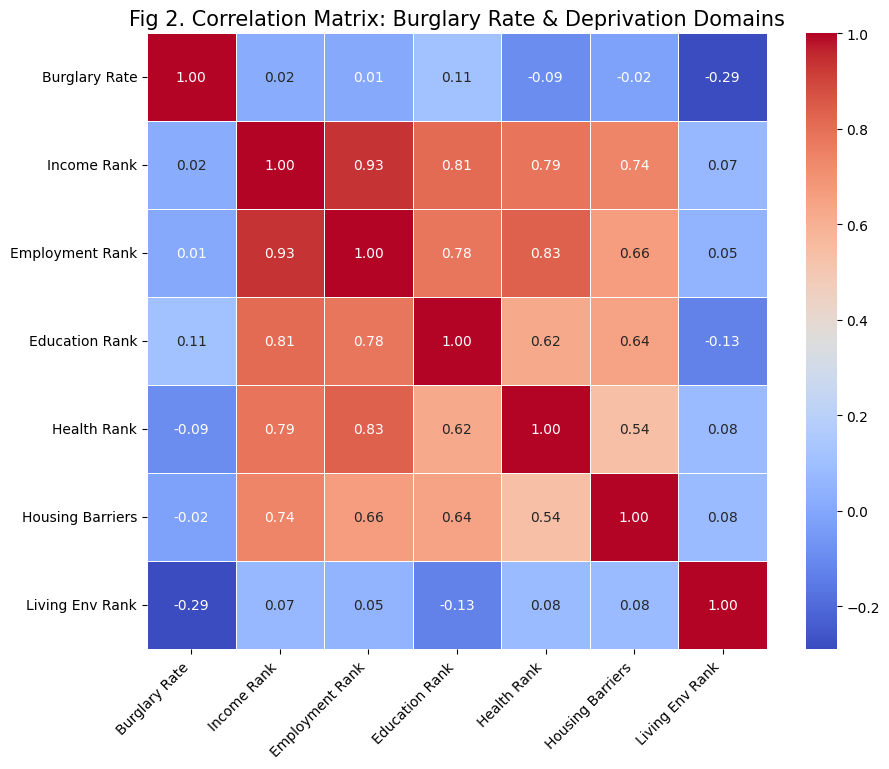

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a mapping dictionary to simplify labels.
rename_dict = {
    'Burglary_Rate_2025(per_1000)': 'Burglary Rate',
    'Income Rank (where 1 is most deprived)': 'Income Rank',
    'Employment Rank (where 1 is most deprived)': 'Employment Rank',
    'Education, Skills and Training Rank (where 1 is most deprived)': 'Education Rank',
    'Health Deprivation and Disability Rank (where 1 is most deprived)': 'Health Rank',
    'Barriers to Housing and Services Rank (where 1 is most deprived)': 'Housing Barriers',
    'Living Environment Rank (where 1 is most deprived)': 'Living Env Rank'
}

# 2. Extract data and rename columns
final_df = final_df[[target_col] + cols_to_use].rename(columns=rename_dict)

# 3. Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(final_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Fig 2. Correlation Matrix: Burglary Rate & Deprivation Domains', fontsize=15)
plt.xticks(rotation=45, ha='right') # 旋转标签防止重叠
plt.show()

Figure 2 illustrates the correlation matrix between the burglary rate and the deprivation domains. It shows that the high inter-correlations exist among the socio-economic domains, with correlation coefficients reaching up to $0.93$, which necessitates the use of VIF analysis to address multicollinearity in the modeling process.

### Introducing VIF Checks 

In [9]:
# 1. Update the short names of the dependent and independent variables
target_col = 'Burglary Rate'
cols_to_use = [
    'Income Rank',
    'Employment Rank', 
    'Education Rank', 
    'Health Rank', 
    'Housing Barriers', 
    'Living Env Rank'
]

from statsmodels.stats.outliers_influence import variance_inflation_factor


# 1. Prepare the feature matrix X, remembering to handle any possible null values
X = final_df[cols_to_use].fillna(0)

# 2. Calculate VIF
vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# 3. print VIF results
print("--- Variance Inflation Factor (VIF) Results ---")
print(vif_df)

--- Variance Inflation Factor (VIF) Results ---
            Feature        VIF
0       Income Rank  29.752111
1   Employment Rank  46.891958
2    Education Rank  13.432151
3       Health Rank  18.428320
4  Housing Barriers   6.360354
5   Living Env Rank   2.761888


Initial VIF testing revealed significant multicollinearity between Income and Employment domains (VIF > 40). To ensure model stability and interpretability, the Employment domain was removed, as its socio-economic information is largely captured by the Income domain.

In [10]:
# 1. Remove the highest Employment_Rank from the VIF
cols_to_use_v2 = [
    'Income Rank', 
    'Education Rank', 
    'Health Rank', 
    'Housing Barriers', 
    'Living Env Rank'
]

# 2. Recalculate VIF
X_v2 = final_df[cols_to_use_v2].fillna(0)
vif_v2 = pd.DataFrame()
vif_v2["Feature"] = X_v2.columns
vif_v2["VIF"] = [variance_inflation_factor(X_v2.values, i) for i in range(len(X_v2.columns))]
print(vif_v2)

            Feature        VIF
0       Income Rank  14.800696
1    Education Rank  12.551935
2       Health Rank  13.314704
3  Housing Barriers   6.298510
4   Living Env Rank   2.756141


After removing the ‘employment ranking’ dimension, the VIF values ​​of the remaining five features decreased significantly (all ≈ 15 or below). Although some degree of multicollinearity still exists among income, education, and health (exceeding the conservative threshold of 10), these areas are retained to ensure coverage of all theoretically relevant poverty dimensions. Following O'Brien (2007), such thresholds should be used cautiously, as a larger sample size can mitigate the effects of multicollinearity. To avoid the interference of multicollinearity, I decide to use tree-based model, which is more robust to multicollinearity.

### Machine Training and Model Selection 

In [11]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score


# 1. prepare data for modeling
X = final_df[cols_to_use_v2].fillna(0)
y = final_df[target_col]

# Divide the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the models to be compared
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Use 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

comparison_results = []

for name, model in models.items():
    # 1. Training Model
    model.fit(X_train, y_train)
    
    # 2. Predict training set and test set
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # 3. Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    r2_cv_mean = np.mean(cv_scores)
    
    comparison_results.append({
        "Model": name, 
        "Train R²": round(r2_train, 4),
        "Test R²": round(r2_test, 4),
        "CV R² (Mean)": round(r2_cv_mean, 4),
        "Test RMSE": round(rmse_test, 4)
    })

# Output comparison table
performance_df = pd.DataFrame(comparison_results)
print("--- 严谨的模型对比结果 ---")
print(performance_df.to_markdown(index=False)) # 如果在 Jupyter 里，可以直接 print(performance_df)

--- 严谨的模型对比结果 ---
| Model         |   Train R² |   Test R² |   CV R² (Mean) |   Test RMSE |
|:--------------|-----------:|----------:|---------------:|------------:|
| Decision Tree |     1      |   -0.4593 |        -0.6539 |      5.8844 |
| Random Forest |     0.8763 |    0.2186 |         0.1513 |      4.3059 |
| XGBoost       |     0.7147 |    0.2056 |         0.0846 |      4.3414 |


The results show that the decision tree model has a Train R² of 1, but its Test R² and CV R² show severely negative values ​​($R^2 < 0$), clearly indicating overfitting. This demonstrates why a simple decision tree alone is insufficient, an ensemble tree model is necessary. 
In contrast, the ensemble-based Random Forest Regressor achieved the highest accuracy ($R^2 = 0.2186, RMSE = 4.3059$), slightly outperforming XGBoost. This outcome justifies the selection of Random Forest as our final model for interpreting the socio-economic drivers of burglary, as it demonstrates superior robustness in handling the inherent multicollinearity between deprivation domains.

### For Global Analysis

The ranking of the contributions of different deprivation indices to the prediction is presented using Feature Importance.

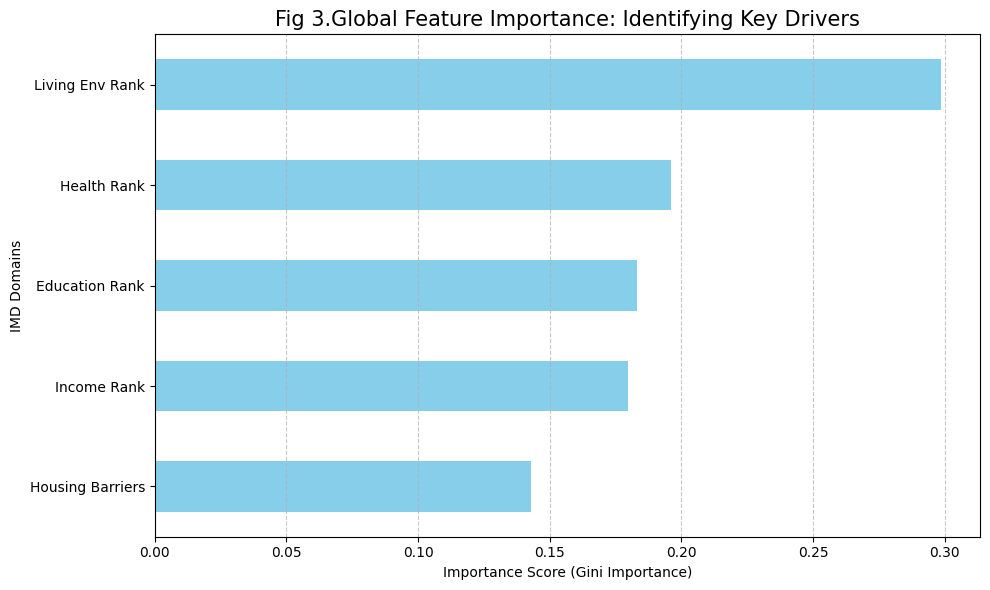

In [12]:
# 1. Extract the trained Random Forest model directly from the comparative experiment
best_model = models["Random Forest"]

# 2. Extract feature importance
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)

# 3. Plot
plt.figure(figsize=(10, 6))
feat_importances.sort_values(ascending=True).plot(kind='barh', color='skyblue')

plt.title('Fig 3.Global Feature Importance: Identifying Key Drivers', fontsize=15)
plt.xlabel('Importance Score (Gini Importance)')
plt.ylabel('IMD Domains')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Figure 3 illustrates that the living environment is the most crucial indicator for predicting burglaries, contributing nearly 30% of the predictive power, which is far more than traditional "income" or "housing" factors. This indicates that in London, burglary is not a random occurrence; it is strongly correlated with the area's comprehensive environmental factors (Bediroglu and Colak, 2024).

After identifying which factors are important, we still don't know whether each factor has a positive or negative impact.  Are burglars driven by desperation to steal from dilapidated neighborhoods, or are they more likely to target upscale neighborhoods for "profit"? To clarify this logic,  I introduced the SHAP beeswarm plot for observation. 

f:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


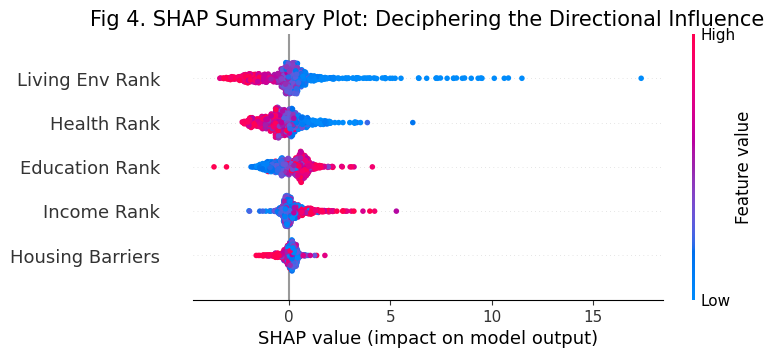

In [13]:
import shap

# 1. Calculate the SHAP value (based on your best-performing model)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Fig 4. SHAP Summary Plot: Deciphering the Directional Influence", fontsize=15)
plt.show()

By using the SHAP plot, focusing directly on the first factor, 'Living Environment Rank,' we can see that the red dots (heavy deprivation/poor environment) are all on the left, while the blue dots (light deprivation/good environment) are all on the right. This illustrates a fact: the better the environment, the higher the predicted burglary rate. This overturns the conventional wisdom that 'poor environments lead to more crime. From a machine learning perspective, this reveals the selection direction of London burglars—they tend to target areas with high environment scores, high property values, and seemingly more 'lucrative' areas (Scott et al., 2019). High-quality environments here are not a barrier to crime, but rather a 'wealth signal' attracting criminals. In contrast, the red dots for income and education (heavy deprivation) are mostly distributed on the right, which aligns with conventional understanding: areas of extreme poverty and low education levels do indeed increase crime predictions. However, combined with Figure 3, the 'impact' of these traditional factors is clearly not as strong as that of environmental factors.

### For Local Analysis

Choosing the LSOA with the highest predicted burglary rate and conducting a local interpretation using the Waterfall plot.

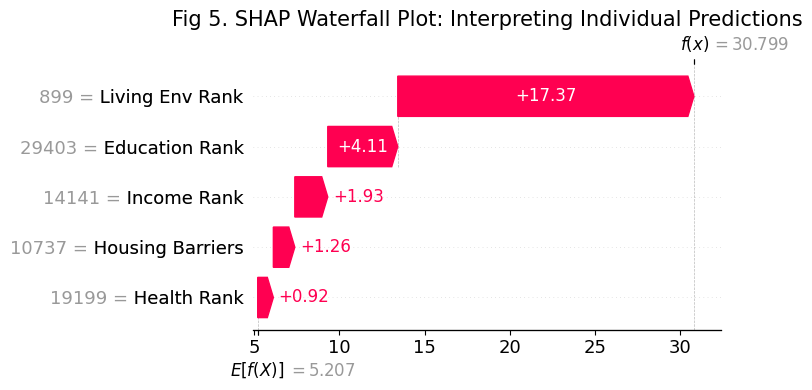

In [14]:
# Use the trained best_model to make predictions on the test set
y_pred = best_model.predict(X_test)

# Find the sample index with the highest predicted crime rate
max_pred_idx = np.argmax(y_pred)

# 1. Extract the SHAP values and expected value for the single sample
shap_val_single = shap_values[max_pred_idx] 
expected_val = explainer.expected_value 

# 2. Plot the Waterfall chart and suppress additional output
plt.figure(figsize=(10, 6))

# Use `_ =` to absorb the function's return value to prevent it from printing unnecessary information
_ = shap.plots.waterfall(
    shap.Explanation(
        values=shap_val_single,
        base_values=expected_val,
        data=X_test.iloc[max_pred_idx],
        feature_names=X_test.columns
    ),
    max_display=10,
    show=False # Tell SHAP not to render yet, let matplotlib take over.
)

plt.title('Fig 5. SHAP Waterfall Plot: Interpreting Individual Predictions', fontsize=15)
plt.tight_layout()
plt.show() # just show the final image

The LSOA with the highest predicted burglary rate (Figure 5) was selected for local SHAP explanation. The base value of the dataset is $E[f(X)] = 5.207$. Notably, the Living Env Rank contributes an increase of $+17.37$ to the prediction, making it by far the most dominant positive driver in high-risk areas.This localized evidence supports the 'Target Attractiveness' hypothesis: The high-risk area is dangerous not because the local residents are poor (with less income or education contribution), but because the area has good environmental quality or high wealth concentration, thus attracting thieves.

### Analysis of Residuals and Policies Thinking

Finally, the residuals were used to identify the points with the largest prediction errors, and the possible causes were analyzed by distinguishing between positive and negative residuals, and intervention policies were discussed.

In [15]:
# Calculate the predicted values ​​and residuals for the test set
y_pred_test = best_model.predict(X_test)
residuals = y_test - y_pred_test

eval_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test,
    'Residual': residuals
}, index=X_test.index)

# 1. Identify the regions where the model significantly underestimates the data 
# (where the residuals are positive and at their maximum)
top_underpredicted = eval_df.nlargest(3, 'Residual')

# 2. Identify the regions where the model significantly overestimates the data 
# (where the residuals are negative and at their minimum)
top_overpredicted = eval_df.nsmallest(3, 'Residual')

print("--- The model severely underestimates the region (Actual > Predicted) ---")
print(top_underpredicted[['Actual', 'Predicted', 'Residual']])
print("\n--- The model severely overestimates the region (Actual < Predicted) ---")
print(top_overpredicted[['Actual', 'Predicted', 'Residual']])

--- The model severely underestimates the region (Actual > Predicted) ---
         Actual  Predicted   Residual
4980  90.589270  30.798985  59.790285
4613  41.044776  10.262991  30.781785
4476  42.145594  17.088026  25.057568

--- The model severely overestimates the region (Actual < Predicted) ---
         Actual  Predicted   Residual
4926   2.870813  25.222405 -22.351591
1818   4.771643  22.146296 -17.374653
2879  10.209870  27.323313 -17.113444


Positive residuals (actual crime rate > predicted value): This indicates that the area possesses certain characteristics that attract crime (e.g., large transportation hubs, bar districts, nightlife venues). Police or planning departments in these areas should not only rely on IMD poverty indicators but should also implement interventions targeting the physical environment (e.g., increasing streetlights, CCTV, and pedestrian surveillance).

Negative residuals (actual crime rate < predicted value): This indicates that although environmental indicators may suggest a high risk area, there are undetected "defense mechanisms" (e.g., active community watch, gated communities, or special security measures). This can provide a model for crime prevention design in other areas.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study successfully demonstrates that residential burglary in London is influenced by multiple dimensions of poverty, showcasing the positive or negative impacts and extent of different indicators on the research objectives. This provides London's local government with a transparent and evidence-based framework.

However, some limitations remain: certain areas identified based on residual diagnostics indicate that socioeconomic indicators alone cannot fully explain the differences in crime rates, suggesting the influence of unobserved environmental or situational factors. Furthermore, the "deprivation index" is a composite indicator, with each domain containing more specific sub-driving factors. Authorities should combine micro-level situational data with more refined socioeconomic indicators to develop more sophisticated, evidence-based policy interventions.

## References

[[ go back to the top ]](#Table-of-contents)

<div style="padding-left: 2em; text-indent: -2em;">
Bediroglu, G. & Colak, H. E. (2024) Predicting and analyzing crime—Environmental design relationship via GIS‐based machine learning approach. Transactions in GIS. [Online] 28 (5), 1377–1399.
</div>

<div style="padding-left: 2em; text-indent: -2em;">
  Chamberlain, A. W. and Boggess, L. N. (2016) Relative Difference and Burglary Location: Can Ecological Characteristics of a Burglar’s Home Neighborhood Predict Offense Location? The journal of research in crime and delinquency. [Online] 53 (6), 872–906.
</div>

<div style="padding-left: 2em; text-indent: -2em;">
Jose Triny, K., Gowri, J. and Padmaja, S., 2023. A Survey on Prediction of Risk Related to Theft Activities in Municipal Areas using Deep Learning. In: 2023 Second International Conference on Electronics and Renewable Systems (ICEARS). Pudukkottai, India, 2-4 March 2023. Piscataway: IEEE. pp. 838–843.
</div>

<div style="padding-left: 2em; text-indent: -2em;">
O’BRIEN, R. M. (2007) A caution regarding rules of thumb for variance inflation factors. Quality & quantity. [Online] 41 (5), 673–690.
</div>



<div style="padding-left: 2em; text-indent: -2em;">
Scott, P., Evans, M. and Southworth, P. (2019) ‘Crime in Britain’s affluent areas is soaring at a faster rate than anywhere else’, <i>The Telegraph</i>, 19 October. Available at: https://www.telegraph.co.uk/news/2019/10/19/crime-britains-affluent-areas-soaring-faster-rate-anywhere-else/ (Accessed: 23 April 2026).
</div>


<div style="padding-left: 2em; text-indent: -2em;">
  Tao, C. and Chen, T., 2021. Urban Crime and Security. In: W. Shi, M. F. Goodchild, M. Batty, M.-P. Kwan and A. Zhang, eds. Urban Informatics. Singapore: Springer. pp. 213–228. Available at: https://doi.org/10.1007/978-981-15-8983-6_14 [Accessed 2 May 2026].
</div>

<div style="padding-left: 2em; text-indent: -2em;">
  Yan, Z., Chen, H., Dong, X., Zhou, K., and Xu, Z.(2022) Research on prediction of multi-class theft crimes by an optimized decomposition and fusion method based on XGBoost. Expert systems with applications. [Online] 207.
</div>